In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tabulate import tabulate as tab

import generate_synthetic_data as gsd


In [2]:
def ref_plot(n, g, Npulses = 1000, txt = 'selection'):
    fig, axs = plt.subplots(1, 2, figsize=(14, 4))
    for i in range(Npulses):
        axs[0].plot(n[i]);
        axs[0].set_title(f'{txt}: neutrons')
    for i in range(Npulses):
        axs[1].plot(g[i]);
        axs[1].set_title(f'{txt}: gammas')
    for i in range(0, 2):
            axs[i].set_xlabel("Pulse Sample", fontsize=12)
            axs[i].set_ylabel("Amplitude [V]", fontsize=12)
            axs[i].grid()
            axs[i].set_xlim(30, 100)
            # axs[i].set_ylim(0, 0.5)
    plt.tight_layout()
    plt.show()

# Read Data and Generate Datasets

In [3]:
data, labels = gsd.read_data_txt(IDs = [10])
data_merged, labels_merged, neutrons_merged, gammas_merged = gsd.merge_cases_together(data, labels)

case    total    gammas    neutrons    ratio (g/n)    Amax total    Amax gammas    Amax neutrons
------  -------  --------  ----------  -------------  ------------  -------------  ---------------
case10  112695   58353     54342       1.1            1.6546        1.6546         0.6824
---     ---      ---       ---         ---            ---           ---            ---
Total   112695   58353     54342       1.1---         ---           ---


### config

In [ ]:
## energy cuts
peak_position_max=60
Vsamples_range=(0.08, 4.0) 
Vpeak_range=(0.05, 999) 
late_window = [20, 200] 
afterpulse_frac = 0.10 
## Templates
amplitudeV = (0.05, 0.35) # no neutrons after 0.35...
Nbins = 6
## Synthetic Samples
sigma_noise = 0.02
min_voltage = 0.05
max_voltage = 0.35 ## cannot go too high because PSD gets distorted
Npulses_train = 40000 
Npulses_val = 160000
## pile-up specific
rate_hz = 1e4 
dt_sampling_s = 2e-9 # from paper (ADC sampling)

# Case = "allCases"
Case = "Case10"
folder = "Synthetic_Datasets_v02"


### Make Samples

Step                       N    eff_abs    eff_rel    N_neutron    eff_neutron    N_gamma    eff_gamma
--------------------  ------  ---------  ---------  -----------  -------------  ---------  -----------
Input                 112695     1.0000     1.0000        54342         1.0000      58353       1.0000
Peak position cut     110658     0.9819     0.9819        52555         0.9671      58103       0.9957
Energy selection      107218     0.9514     0.9689        52452         0.9652      54766       0.9385
Amplitude cut          37678     0.3343     0.3514        11982         0.2205      25696       0.4404
Afterpulse rejection   32412     0.2876     0.8602         6718         0.1236      25694       0.4403


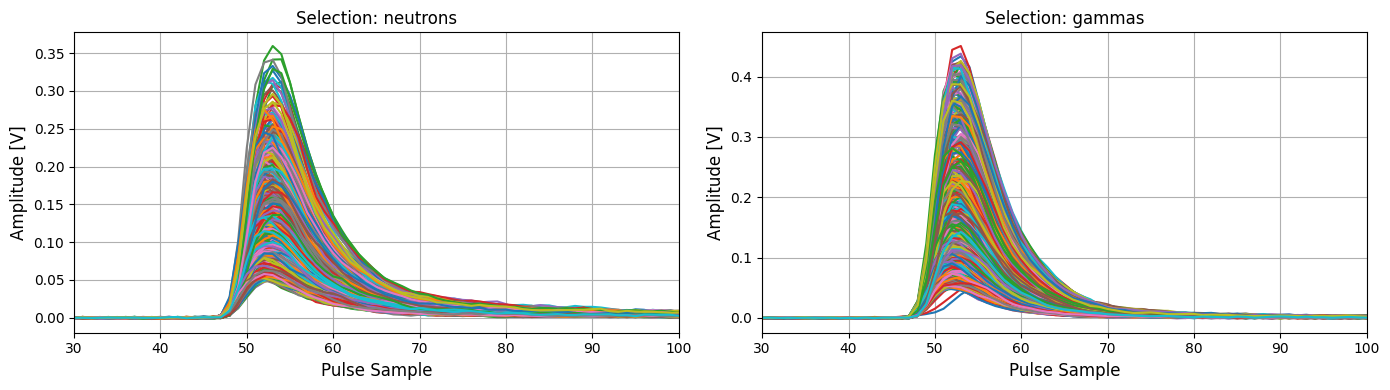

bin_edges [0.05 0.1  0.15 0.2  0.25 0.3  0.35]
bin_centers [0.075 0.125 0.175 0.225 0.275 0.325]

neutrons
 sample shape (6718, 296)
 peak amplitude (min, max) -0.0018 0.3595
 average peak amplitude 0.005922586154180383
 counts per bin: [2871 1956  974  598  246   70]

gammas
 sample shape (25694, 296)
 peak amplitude (min, max) -0.0022 0.4556
 average peak amplitude 0.004952052403652967
 counts per bin: [10432  5294  3569  2204  1592  1179]


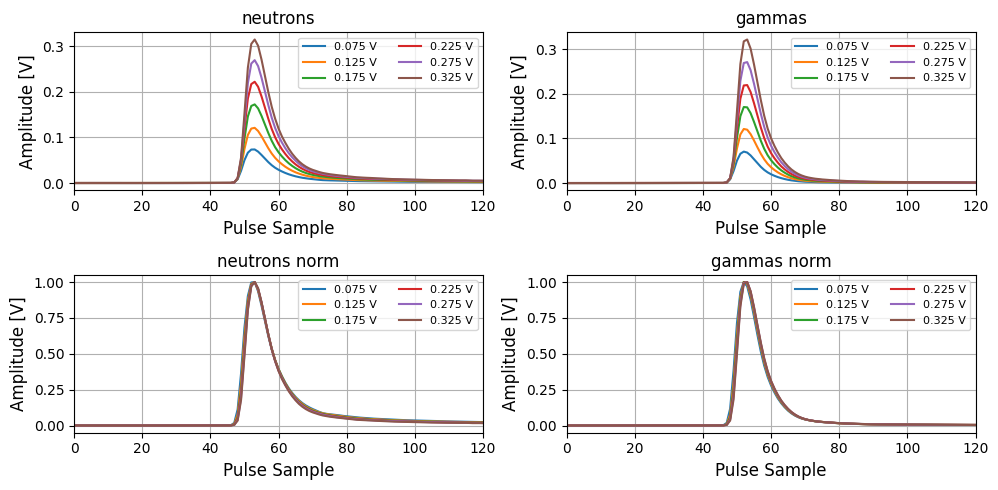

In [5]:
# --------------------------------------------------
# Selection
# --------------------------------------------------
data_sel, labels_sel, cutflow = gsd.tight_selection(data_merged, labels_merged, 
                                                  Vsamples_range, 
                                                  Vpeak_range,
                                                  peak_position_max,
                                                  late_window, 
                                                  afterpulse_frac)

df = gsd.cutflow_table(cutflow)

ref_plot(data_sel[labels_sel==1], data_sel[labels_sel==0], Npulses = 1000, txt = 'Selection')

# --------------------------------------------------
# Templates
# --------------------------------------------------
neutrons_sel = data_sel[labels_sel == 1]
gammas_sel   = data_sel[labels_sel == 0]
bin_edges = np.linspace(amplitudeV[0], amplitudeV[1], Nbins+1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
print('bin_edges', bin_edges)
print('bin_centers', bin_centers)
print('\nneutrons')
_, templates_n, templates_n_norm = gsd.make_templates(neutrons_sel, bin_edges, align = False)
print('\ngammas')
_, templates_g, templates_g_norm = gsd.make_templates(gammas_sel, bin_edges, align = False) ## something here -> align not really working; makes PSD look worse...

# ref_plot(templates_n, templates_g, Npulses = Nbins, txt = 'Templates')
# ref_plot(templates_n_norm, templates_g_norm, Npulses = Nbins, txt = 'Normalized Templates')
fig, axs = plt.subplots(2, 2, figsize=(10, 5))
axs = axs.flatten()
axs[0].set_title(f'neutrons')
axs[1].set_title(f'gammas')
axs[2].set_title(f'neutrons norm')
axs[3].set_title(f'gammas norm')
for i in range(Nbins):
    axs[0].plot(templates_n[i], label=f"{bin_centers[i]:.3f} V")
    axs[1].plot(templates_g[i], label=f"{bin_centers[i]:.3f} V")
    axs[2].plot(templates_n_norm[i], label=f"{bin_centers[i]:.3f} V")
    axs[3].plot(templates_g_norm[i], label=f"{bin_centers[i]:.3f} V")

for i in range(0, 4):
    axs[i].set_xlabel("Pulse Sample", fontsize=12)
    axs[i].set_ylabel("Amplitude [V]", fontsize=12)
    axs[i].legend(ncol=2, fontsize=8)
    axs[i].grid()
    axs[i].set_xlim(0, 120)
    # axs[i].set_ylim(0, 0.5)
plt.tight_layout()
plt.show()


In [6]:
# --------------------------------------------------
# Synthetic Samples Training
# --------------------------------------------------
X_train, Y_train = [], []
print('NEUTRONS')
neutrons_synth, _ = gsd.generate_sample(templates = templates_n_norm, 
                                 bin_centers =  bin_centers, 
                                 Npulses = Npulses_train, 
                                 sigma = sigma_noise,
                                 A_min=min_voltage, 
                                 A_max=max_voltage,
                                 Normalize=True) # must be normalized for ML
neutrons_label = np.ones(neutrons_synth.shape[0])

print('GAMMAS')
gammas_synth, _ = gsd.generate_sample(templates = templates_g_norm, 
                                 bin_centers =  bin_centers, 
                                 Npulses = Npulses_train, 
                                 sigma = sigma_noise,
                                 A_min=min_voltage, 
                                 A_max=max_voltage,
                                 Normalize=True) 
gammas_label = np.zeros(gammas_synth.shape[0])

print(f'PILEUP')
## get the position of the peaks in the templates (averaged over all templates)
peak_idxes = np.concat([ np.argmax(templates_n_norm, axis=1), np.argmax(templates_g_norm, axis=1)])
meanPeak_idx = int(np.ceil( np.mean(peak_idxes)  ))
piluep_synth, time_shifts_pileup_train = gsd.generate_pileup_sample(
                                Npulses_train, templates_n_norm, templates_g_norm, bin_centers,
                                peak_amplitude_range_V = [min_voltage, max_voltage],
                                rate_hz = rate_hz, dt_sampling_s = dt_sampling_s, margin_samples = meanPeak_idx,  
                                noise_sigma = sigma_noise,
                                Normalize=True)
piluep_label = np.ones(piluep_synth.shape[0])*2


X_train = np.concatenate((neutrons_synth, gammas_synth, piluep_synth), axis=0)
Y_train = np.concatenate((neutrons_label, gammas_label, piluep_label), axis=0)
print('\nX shape', X_train.shape)
print('sanity check, Y shape', Y_train.shape)
print('time_shifts shape (pile-up only)', time_shifts_pileup_train.shape)

np.savez(
    f"{folder}/synthetic_training_{Case}_120k_noise_{sigma_noise}.npz",
    X=X_train,
    y=Y_train,
    meta=time_shifts_pileup_train   # any third array (labels, dt, class, etc.)
)



NEUTRONS
Clamped fraction: 0.083775
GAMMAS
Clamped fraction: 0.083275
PILEUP

X shape (120000, 296)
sanity check, Y shape (120000,)
time_shifts shape (pile-up only) (40000,)


In [7]:
# --------------------------------------------------
# Synthetic Samples Validation
# --------------------------------------------------
X_val, Y_val = [], []
print('NEUTRONS')
neutrons_synth, _ = gsd.generate_sample(templates = templates_n_norm, 
                                 bin_centers =  bin_centers, 
                                 Npulses = Npulses_val, 
                                 sigma = sigma_noise,
                                 A_min=min_voltage, 
                                 A_max=max_voltage,
                                 Normalize=False) 
neutrons_label = np.ones(neutrons_synth.shape[0])

print('GAMMAS')
gammas_synth, _ = gsd.generate_sample(templates = templates_g_norm, 
                                 bin_centers =  bin_centers, 
                                 Npulses = Npulses_val, 
                                 sigma = sigma_noise,
                                 A_min=min_voltage, 
                                 A_max=max_voltage,
                                 Normalize=False) 
gammas_label = np.zeros(gammas_synth.shape[0])

print(f'PILEUP')
## get the position of the peaks in the templates (averaged over all templates)
peak_idxes = np.concat([ np.argmax(templates_n_norm, axis=1), np.argmax(templates_g_norm, axis=1)])
meanPeak_idx = int(np.ceil( np.mean(peak_idxes)  ))
piluep_synth, time_shifts_pileup_val = gsd.generate_pileup_sample(
                                Npulses_train, templates_n_norm, templates_g_norm, bin_centers,
                                peak_amplitude_range_V = [min_voltage, max_voltage],
                                rate_hz = rate_hz, dt_sampling_s = dt_sampling_s, margin_samples = meanPeak_idx,  
                                noise_sigma = sigma_noise,
                                Normalize=True)
piluep_label = np.ones(piluep_synth.shape[0])*2

X_val = np.concatenate((neutrons_synth, gammas_synth, piluep_synth), axis=0)
Y_val = np.concatenate((neutrons_label, gammas_label, piluep_label), axis=0)
print('\nX shape', X_val.shape)
print('sanity check, Y shape', Y_val.shape)
print('time_shifts shape (pile-up only)', time_shifts_pileup_val.shape)

np.savez(
    f"{folder}/synthetic_validation_{Case}_480k_noise_{sigma_noise}.npz",
    X=X_val,
    y=Y_val,
    meta=time_shifts_pileup_val   # any third array (labels, dt, class, etc.)
)



NEUTRONS
Clamped fraction: 0.083125
GAMMAS
Clamped fraction: 0.0846
PILEUP

X shape (360000, 296)
sanity check, Y shape (360000,)
time_shifts shape (pile-up only) (40000,)
